In [20]:
!pip install astropy
!pip install photutils 
import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u
import astropy.constants as const
from astropy.io import fits
import scipy 
import urllib.request
import os 
from scipy import optimize
import photutils.detection as detect

In [21]:
NGC2660_555_fits = "hst_10634_03_acs_wfc_f555w_j9dm03_drc.fits"
NGC2660_814_fits = "hst_10634_03_acs_wfc_f814w_j9dm03_drc.fits"
NGC2660_fits = "hst_10634_03_acs_wfc_total_j9dm03.fits"
NGC2660_fits_url = "https://hla.stsci.edu/cgi-bin/getdata.cgi?config=ops&dataset=hst_10634_03_acs_wfc_total_j9dm03"
NGC2660_555_fits_url = "https://hla.stsci.edu/cgi-bin/getdata.cgi?config=ops&download=1&dataset=hst_10634_03_acs_wfc_total_j9dm03&filename=hst_10634_03_acs_wfc_f555w_j9dm03_drc.fits"
NGC2660_814_fits_url = "https://hla.stsci.edu/cgi-bin/getdata.cgi?config=ops&download=1&dataset=hst_10634_03_acs_wfc_total_j9dm03&filename=hst_10634_03_acs_wfc_f814w_j9dm03_drc.fits"

if not os.path.exists(NGC2660_814_fits) & os.path.exists(NGC2660_555_fits):
        try:
            urllib.request.urlretrieve(NGC2660_814_fits_url, NGC2660_814_fits)
            print(f"Downloaded {NGC2660_814_fits}")
            urllib.request.urlretrieve(NGC2660_555_fits_url, NGC2660_555_fits)
            print(f"Downloaded {NGC2660_555_fits}")
        except Exception as e:
            print("Error Downloading File")
            NGC2660_555_fits = None
            NGC2660_814_fits = None

In [22]:
from matplotlib.colors import LogNorm

bands = [NGC2660_555_fits, NGC2660_814_fits]
image_data = []
for b in bands:
    with fits.open(b) as HDUList:
        image_data.append(HDUList[1].data) #reads the data from the SCI section of the fits file
        HDUList.close()
image_555, image_814 = image_data

sigma = 3
fwhm = 2.355 * sigma


In [ ]:
clipped_data_555 = image_555.copy()
for i in range(5):
    mean = np.nanmean(clipped_data_555)
    std = np.nanstd(clipped_data_555)
    mask = np.abs(clipped_data_555 - mean) <= 3 * std
    clipped_data = clipped_data_555[mask]
    background_mean_555 = np.mean(clipped_data)




clipped_data_814 = image_814.copy()
for i in range(5):
    mean = np.nanmean(clipped_data_814)
    std = np.nanstd(clipped_data_814)
    mask = np.abs(clipped_data_814 - mean) <= 3 * std
    clipped_data = clipped_data_814[mask]
    background_mean_814 = np.mean(clipped_data)




#gaussian_PSF

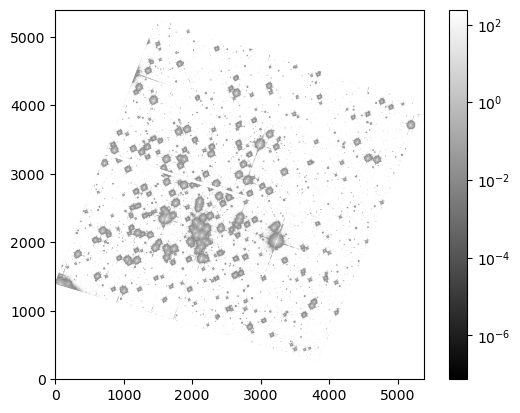

(array([6.220000e+02, 1.470100e+04, 6.970070e+05, 6.546433e+06,
        6.149396e+06, 1.360588e+06, 4.191260e+05, 2.209370e+05,
        1.453760e+05, 1.051600e+05, 8.035400e+04, 6.481100e+04,
        5.367200e+04, 4.488800e+04, 3.758500e+04, 3.253500e+04,
        2.810000e+04, 2.442800e+04, 2.146900e+04, 1.908600e+04,
        1.674400e+04, 1.511500e+04, 1.332900e+04, 1.196300e+04,
        1.061500e+04, 9.828000e+03, 9.078000e+03, 8.166000e+03,
        7.558000e+03, 7.030000e+03, 6.450000e+03, 5.924000e+03,
        5.632000e+03, 5.145000e+03, 4.856000e+03, 4.717000e+03,
        4.269000e+03, 3.979000e+03, 3.837000e+03, 3.568000e+03,
        3.366000e+03, 3.216000e+03, 3.042000e+03, 3.020000e+03,
        2.826000e+03, 2.620000e+03, 2.511000e+03, 2.406000e+03,
        2.289000e+03, 2.338000e+03]),
 array([-0.1       , -0.083     , -0.066     , -0.049     , -0.032     ,
        -0.015     ,  0.002     ,  0.019     ,  0.036     ,  0.053     ,
         0.07      ,  0.087     ,  0.104     ,  

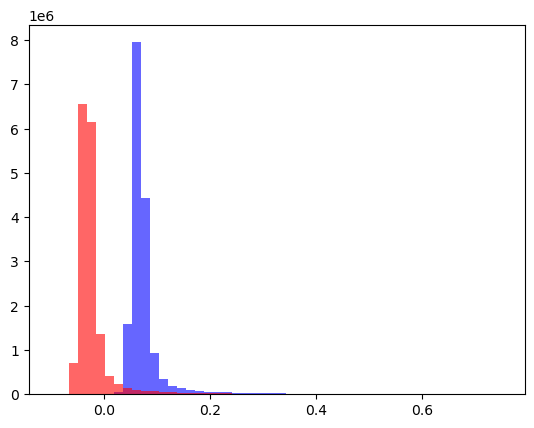

In [24]:
subtracted_image_555 = image_555 - background_mean_555

plt.figure()
plt.imshow(subtracted_image_555, cmap='grey', origin = 'lower', norm=LogNorm())
plt.colorbar(norm=LogNorm())
plt.show()

fig, axes = plt.subplots()
axes.hist(image_555.flatten(), bins=50, color='blue', range=(-.1, .75), alpha=.6)
axes.hist(subtracted_image_555.flatten(), bins=50, color='red', range=(-.1, .75), alpha=.6)

0.09751291
0.48756453
 id x_peak y_peak peak_value
--- ------ ------ ----------
  1   3231   2008  242.41061
  2   4107    968  235.84583
  3   5187   3702  233.49498
  4   3634    934  233.25421
  5   3190   2210  232.13773
  6   4101   1408  227.68533
  7   3747   1066  226.90038
  8   2777   1778   226.2516
  9   3616   1573  225.79086
 10   3350   1728  224.94804
...    ...    ...        ...
191   2298   1434  196.79942
192   2868   4146  196.55034
193   1889   3342  196.52748
194   1813   2877  196.08607
195   3262   3491  195.78769
196   3001   1816  195.69519
197   2903   3772  195.56503
198   2368   1188  194.88678
199   2897   2941  194.53185
200   2640   4389  194.50577
Length = 200 rows


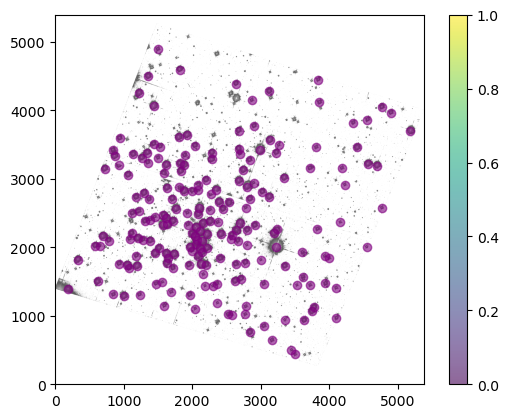

In [102]:
subtracted_image_555 = image_555 - background_mean_555
subtracted_image_814 = image_814 - background_mean_814
print(background_mean_555)
detection_threshold =  5 * background_mean_555
print(detection_threshold)
filter = int(np.ceil(fwhm))


detections =  detect.find_peaks(data=subtracted_image_555, threshold=detection_threshold, mask=mask*1000, min_separation=50 , n_peaks=200)
print(detections)
detections_x = detections['x_peak']
detections_y = detections['y_peak']

plt.figure()
plt.imshow(subtracted_image_555, cmap='grey', origin = 'lower', norm=LogNorm(vmin = .0001, vmax=300))
plt.scatter(detections_x, detections_y, color = 'purple', alpha =.6, marker='o', )
plt.colorbar(norm=LogNorm(vmin = .0001, vmax=300))
plt.show()


#axes[2].hist(image_data.flatten(), bins=50, color='blue', range=(-.1, .75), alpha=.6)
#axes[2].hist(subtracted_image.flatten(), bins=50, color='red', range=(-.1, .75), alpha=.6)

In [92]:
class Star:
    """One star is the coordinates of the center of a star on the image"""
    
    def __init__(self, row, col, name=""):
        self.row = row
        self.col = col
        self.name = name

    def get_row_col(self):
        return (self.row, self.col)

    def value_at(self, image):
        return image[self.row, self.col]

    def cutout(self, image, half_size=8):
        nrows, ncols = image.shape
        r_start = self.row - half_size
        r_end = self.row + half_size + 1
        c_start = self.col - half_size + 1
        c_end = self.col + half_size + 1
        if r_start < 0:
            r_start = 0
        if c_start < 0: 
            c_start = 0
        if r_end > nrows:
            r_end = nrows
        if c_end > ncols:
            c_end = ncols
        return image[r_start:r_end, c_start:c_end]



<function matplotlib.pyplot.show(close=None, block=None)>

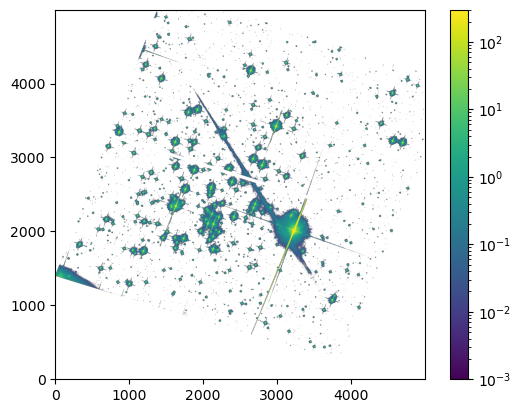

In [229]:
plt.imshow(subtracted_image_814[0:5000, 0:5000], origin='lower', norm=LogNorm(vmin = .001, vmax = 300), cmap = 'viridis')
plt.colorbar()
plt.show

In [226]:
stars = [
    Star(1311, 1231, "1"),
    Star(544, 3297, "2"),
    Star(2910, 4128, "3"),
    Star(4462, 1557, "4"),
    Star(1657, 2605, "5"),
    Star(4064, 1437, "6"),
    Star(2160, 690, "7"),
    Star(4531, 1714, "8"),
    Star(2010, 3230, "9"),
    Star(2710, 1710, "10"),
    Star(4531, 1713, "11"),
    Star(4168, 2647, "12"),
    Star(3565, 3130, "13"),
    Star(3203, 1623, "14"),
    Star(2228, 2120, "15"),
    Star(2888, 2795, "16"),
    Star(2015, 2177, "18"),
    Star(3056, 1063, "19"),
    Star(4116, 3859, "20"),
    Star(3333, 866, "21"),
    Star(2340, 1630, "22"),
    Star(1880, 2087, "23"),
    Star(1900, 1738, "24"),
    Star(2003, 1967, "25"),
    Star(1953, 1999, "26"),
    Star(1988, 2106, "27"),
    Star(2016, 2176, "28"),
    Star(2193, 2216, "29"),
    Star(1433, 2298, "30")
    ]


#for i in  range(len(detections)):
#    stars.append(Star(detections_x[i], detections_y[i]))
#print(len(stars))

In [ ]:

flux = []

def psf_fit(coords, row, col, sigma=3, amplitude_func=70, offset=0):
    x, y = coords
    

    psf = amplitude_func * np.exp(-((y-row)**2 + (x-col)**2)/(2*sigma**2))
    fwhm = 2.355*sigma
    return psf.ravel()

def image_2660(selected_image):
    for s in stars:
        cutout = s.cutout(image=selected_image)
        nonan_cutout = np.nan_to_num(cutout)
        y_size, x_size = nonan_cutout.shape
        yy, xx = np.meshgrid(np.arange(y_size), np.arange(x_size), indexing='ij') 
        xdata = (yy, xx)
        ydata = nonan_cutout.ravel()
        ydata = np.nan_to_num(ydata, nan=np.nanmedian(ydata))
        peak = np.max(ydata)
        bg = np.median(ydata)
        flux.append(2 * np.pi * peak * 2**2)

        lower_bounds = [0, 0, 0.5, 0, -np.inf]
        upper_bounds = [y_size, x_size, 10.0, np.inf, np.inf]
        
        p0 = [
        y_size / 2,
        x_size / 2,
        1.0,
        peak - bg,
        bg

        ]
        popt, pcov = optimize.curve_fit(
            psf_fit,
            xdata,
            ydata,
            p0=p0,
            bounds=(lower_bounds, upper_bounds),
            maxfev=20000
            )         
        actual_data = ydata.reshape(y_size, x_size)
        fit_model = psf_fit(xdata, *popt).reshape(y_size, x_size)
        mask_data = (actual_data - fit_model) > 100.
        print(actual_data.shape)
        #actual_data[mask_data] = np.nan
        masked_popt, mask_pcov = optimize.curve_fit(
            psf_fit,
            xdata,
            actual_data,
            p0=p0,
            bounds = (lower_bounds, upper_bounds),
            maxfev=20000,
            nan_policy = 'omit'
            )

        fit_model = psf_fit(xdata, *masked_popt).reshape(y_size, x_size)
        actual_data = ydata.reshape(y_size, x_size)
        fig, ax = plt.subplots(1, 3, figsize=(15, 5))

        im0 = ax[0].imshow(actual_data, origin='lower')
        ax[0].set_title('Actual Star (Data)')
        fig.colorbar(im0, ax=ax[0])
        
        im1 = ax[1].imshow(fit_model, origin='lower')
        ax[1].set_title('Best Fit')
        fig.colorbar(im1, ax=ax[1])
        
        im2 = ax[2].imshow(actual_data - fit_model, origin='lower')
        ax[2].set_title('Residuals (Data - Model)')
        fig.colorbar(im2, ax=ax[2]) 
        print(f"popt {popt}")
image_2660(subtracted_image_555)
image_2660(subtracted_image_814)
print(f"flux {flux}")

(17, 16)


ValueError: non-broadcastable output operand with shape (16,) doesn't match the broadcast shape (17,16)

flux_555 [5266.194      80.236084  246.13202   226.5246    688.84985  5062.9644
 5565.3105    895.65576  6092.4434   5387.8237    895.65576  4872.5635
 4952.0356   5169.1304   5382.0093   5366.43     5370.638    5394.1333
 5017.021    5138.2866   5615.385    5501.2393   5426.742    5426.119
 5024.8594   5402.5225   5370.638    5598.3247   4946.109   ]
flux_814 [5655.5566   457.66074  900.6031   915.0482  2460.4385  5151.44
 5656.491   2834.2292  6058.101   5603.888   2834.2292  5208.326
 5260.482   5194.0996  5605.9565  5347.416   5400.916   5362.0947
 5186.305   5163.491   5885.2944  5700.301   5700.6494  5585.651
 5332.455   5421.9697  5400.916   5658.328   5506.515  ]
flux_subtraction [ -389.3628    -377.42465   -654.47107   -688.5236   -1771.5886
   -88.475586   -91.180664 -1938.5735      34.342285  -216.06445
 -1938.5735    -335.7627    -308.4463     -24.969238  -223.94727
    19.01416    -30.277832    32.038574  -169.28418    -25.20459
  -269.90967   -199.06152   -273.90723   -15

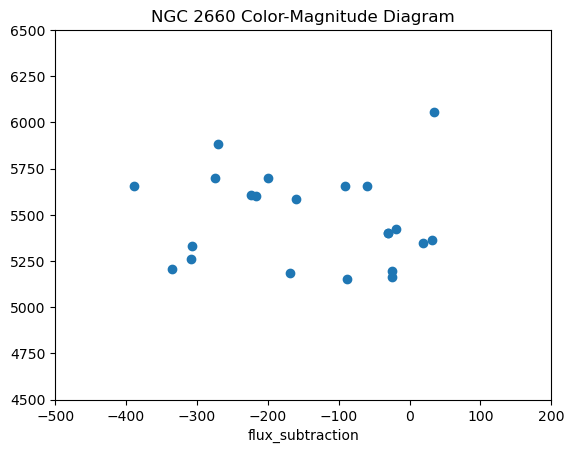

In [228]:
#im pretty sure the 555 is the first set of data but not sure
flux_split = len(flux)//2 
intensity_555 = np.asarray(flux[:flux_split])
intensity_814 = np.asarray(flux[flux_split:])
print(f"flux_555 {intensity_555}")
print(f"flux_814 {intensity_814}")
flux_subtraction = intensity_555 - intensity_814
print(f"flux_subtraction {flux_subtraction}")

plt.scatter(flux_subtraction, intensity_814)
plt.xlim(-500, 200)
plt.ylim(4500, 6500)
plt.xlabel("flux_subtraction")
plt.title("NGC 2660 Color-Magnitude Diagram")
plt.show()
